In [1]:
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import os
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
base_dir   = '/kaggle/input/datasets/raphalperon/data-scap/patient/patient/'
output_dir = '/kaggle/working/'

In [2]:
#Étape 1 : Pré-traitement et extraction de patches
#Cette étape convertit les volumes 3D en petits patches pour l'entraînement du modèle.
patches_ct = [] #Liste pour stocker les cubes de scanner (données d'entrée)
patches_masque = [] #Liste pour stocker les cubes de segmentation (vérité terrain)
patients_valides = 0 #Compteur de patients traités avec succès

for dossier in sorted(os.listdir(base_dir)):
    #Exclusion du patient s0224 réservé exclusivement à l'inférence
    if dossier == 's0224':
        continue
        
    #Arrêt si le quota de patches est atteint
    if len(patches_ct) >= 10000:
        break

    dossier_path = os.path.join(base_dir, dossier)
    if not os.path.isdir(dossier_path):
        continue
    ct_path = os.path.join(dossier_path, 'ct.nii')
    if not os.path.exists(ct_path):
        continue

    #Chargement du scanner et conversion en float32 pour le calcul
    ct = nib.load(ct_path).get_fdata().astype(np.float32)
    
    #Normalisation : on se focalise sur les tissus mous et l'os (-200 à 1800 HU)
    ct = np.clip(ct, -200, 1800)
    ct = (ct - (-200)) / (1800 - (-200))

    #Fusion des masques gauche et droit pour obtenir une segmentation globale
    masque_global = np.zeros(ct.shape, dtype=np.uint8)
    for nom in ['humerus_left', 'humerus_right']:
        masque_path = os.path.join(dossier_path, 'segmentations', f'{nom}.nii')
        if os.path.exists(masque_path):
            masque_local = (nib.load(masque_path).get_fdata() > 0).astype(np.uint8)

            #Correction de l'orientation si nécessaire (différence entre CT (z,y,x) et NIfTI (x,y,z))
            if masque_local.shape != ct.shape:
                masque_local = np.transpose(masque_local, (2, 1, 0))
            if masque_local.shape == ct.shape:
                masque_global = np.clip(masque_global + masque_local, 0, 1)

    #On ignore les volumes dont la segmentation est trop faible (< 30k voxels)
    if masque_global.sum() < 30000:
        del ct, masque_global
        continue
    #Découpage en patches de 64x64x64 avec un chevauchement de 50% (pas de 32)
    taille, pas = 64, 32
    z_max, y_max, x_max = ct.shape
    n = 0
    
    for z in range(0, z_max - taille + 1, pas):
        for y in range(0, y_max - taille + 1, pas):
            for x in range(0, x_max - taille + 1, pas):

               
                if len(patches_ct) >= 10000:
                    break

                patch_masque = masque_global[z:z+taille, y:y+taille, x:x+taille]
                patch_ct     = ct[z:z+taille,            y:y+taille, x:x+taille]
                #On garde le patch s'il contient de la scapula (masque) 
                #OU s'il contient de l'os dense (HU > 800) pour apprendre au modèle à ne pas confondre les structures.
                if patch_masque.sum() > 50 or patch_ct.max() > 0.5:
                    #Stockage en float16 pour optimiser l'occupation de la RAM
                    patches_ct.append(patch_ct.astype(np.float16))
                    patches_masque.append(patch_masque.astype(np.uint8))
                    n += 1
            else:
                continue
            break
        else:
            continue
        break

    patients_valides += 1
    print(f"{dossier} → {n} patches | total : {len(patches_ct)}")
    del ct, masque_global #Libération de la mémoire

print(f"\n{patients_valides} patients | {len(patches_ct)} patches")

s0035 → 153 patches | total : 153
s0331 → 171 patches | total : 324
s0332 → 497 patches | total : 821
s0334 → 464 patches | total : 1285
s0382 → 247 patches | total : 1532
s0412 → 463 patches | total : 1995
s0439 → 205 patches | total : 2200
s0457 → 143 patches | total : 2343
s0467 → 663 patches | total : 3006
s0482 → 201 patches | total : 3207
s0511 → 437 patches | total : 3644
s0556 → 616 patches | total : 4260
s0585 → 285 patches | total : 4545
s0589 → 386 patches | total : 4931
s0591 → 567 patches | total : 5498
s0592 → 508 patches | total : 6006
s0597 → 158 patches | total : 6164
s0605 → 202 patches | total : 6366
s0616 → 640 patches | total : 7006
s0627 → 117 patches | total : 7123
s0650 → 696 patches | total : 7819
s0667 → 558 patches | total : 8377
s0690 → 400 patches | total : 8777
s0691 → 322 patches | total : 9099
s0727 → 480 patches | total : 9579
s0751 → 421 patches | total : 10000

26 patients | 10000 patches


In [3]:
#Étape 2 : Chargement du Dataset
#On recharge les patches précalculés pour l'entraînement du modèle.
#Note : On conserve le typage float16/uint8 pour limiter l'empreinte mémoire.
import gc
patches = np.load('/kaggle/input/datasets/raphalperon/data-scap/patches_ct.npy',     mmap_mode='r')
masques = np.load('/kaggle/input/datasets/raphalperon/data-scap/patches_masque.npy', mmap_mode='r')
patches_tensor = torch.from_numpy(np.array(patches)).unsqueeze(1)   # (N,1,64,64,64) float16
masques_tensor = torch.from_numpy(np.array(masques)).unsqueeze(1).half()

del patches, masques
gc.collect()
print(f"RAM tenseurs : {patches_tensor.nbytes/1e9:.1f} Go ")
 


RAM tenseurs : 6.6 Go  (stable jusqu'à la fin)


In [3]:
#Étape 2 : Chargement du Dataset
#On recharge les patches précalculés pour l'entraînement du modèle.
#Note : On conserve le typage float16/uint8 pour limiter l'empreinte mémoire.
import gc
#Convertion en tensor 
patches_tensor = torch.from_numpy(np.array(patches_ct,     dtype=np.float16)).unsqueeze(1)
masques_tensor = torch.from_numpy(np.array(patches_masque, dtype=np.uint8)).unsqueeze(1).half()

del patches_ct, patches_masque
gc.collect()
print(f"Tenseurs prêts : {patches_tensor.nbytes/1e9:.1f} Go")

Tenseurs prêts : 5.2 Go


In [5]:
#Sauvegarde des tenseurs
torch.save(patches_tensor, output_dir + 'patches_tensor.pt')
torch.save(masques_tensor, output_dir + 'masques_tensor.pt')

In [6]:
#Chargements des tenseurs
patches_tensor = torch.load('/kaggle/input/datasets/raphalperon/data-scap/patches_tensor.pt')
masques_tensor = torch.load('/kaggle/input/datasets/raphalperon/data-scap/masques_tensor.pt')
print(f"Tenseurs chargés : {patches_tensor.nbytes/1e9:.1f} Go")

Tenseurs chargés : 5.2 Go


Device : cuda
Utilisation de 2 GPUs
Epoch 01/25 | Train : 1.2114 | Val : 1.1092
  Meilleur modèle sauvegardé ! (val=1.1092)
Epoch 02/25 | Train : 1.0383 | Val : 1.0173
  Meilleur modèle sauvegardé ! (val=1.0173)
Epoch 03/25 | Train : 0.9211 | Val : 1.1185
  Pas d'amélioration (1/5)
Epoch 04/25 | Train : 0.7718 | Val : 0.6859
  Meilleur modèle sauvegardé ! (val=0.6859)
Epoch 05/25 | Train : 0.6731 | Val : 1.2098
  Pas d'amélioration (1/5)
Epoch 06/25 | Train : 0.6000 | Val : 0.6204
  Meilleur modèle sauvegardé ! (val=0.6204)
Epoch 07/25 | Train : 0.5486 | Val : 0.5651
  Meilleur modèle sauvegardé ! (val=0.5651)
Epoch 08/25 | Train : 0.5304 | Val : 0.5917
  Pas d'amélioration (1/5)
Epoch 09/25 | Train : 0.4974 | Val : 0.5535
  Meilleur modèle sauvegardé ! (val=0.5535)
Epoch 10/25 | Train : 0.4875 | Val : 0.5459
  Meilleur modèle sauvegardé ! (val=0.5459)
Epoch 11/25 | Train : 0.4301 | Val : 0.5478
  Pas d'amélioration (1/5)
Epoch 12/25 | Train : 0.4325 | Val : 0.4418
  Meilleur modèle sa

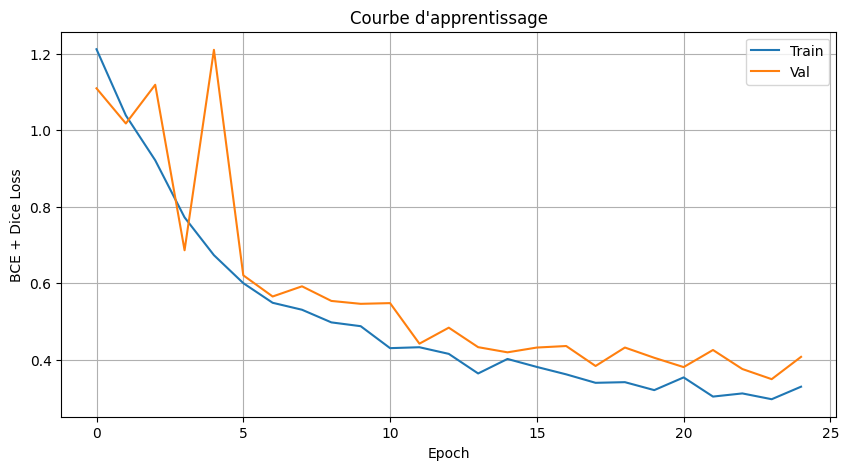


  Meilleur val loss : 0.3490 — Dice : 0.825


In [7]:
#Étape 3 : Entraînement du modèle UNet 3D
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import os
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import gc

base_dir   = '/kaggle/input/datasets/raphalperon/data-scap/patient/patient/'
output_dir = '/kaggle/working/'

#bloc double convolution classique pour l'extraction de caractéristiques spatiales.
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.encodeur = nn.ModuleList()
        self.pool     = nn.MaxPool3d(kernel_size=2, stride=2)
        #Partie descendante (Encoder)
        for feature in features:
            self.encodeur.append(DoubleConv(in_channels, feature))
            in_channels = feature
        self.fond = DoubleConv(features[-1], features[-1] * 2)
        self.decodeur_up   = nn.ModuleList()
        self.decodeur_conv = nn.ModuleList()

        #Partie ascendante (Decoder)
        for feature in reversed(features):
            self.decodeur_up.append(
                nn.ConvTranspose3d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decodeur_conv.append(DoubleConv(feature * 2, feature))
        self.sortie  = nn.Conv3d(features[0], out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        skip_connections = []
        for couche in self.encodeur:
            x = couche(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.fond(x)
        skip_connections = skip_connections[::-1]
        for i in range(len(self.decodeur_up)):
            x    = self.decodeur_up[i](x)
            skip = skip_connections[i]
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.decodeur_conv[i](x)
        return self.sigmoid(self.sortie(x))

#Loss fonction qui combine Dice Loss (pour la forme) et BCE pondéré (pour gérer le déséquilibre fond/scapula).
def bce_dice_loss(prediction, cible, epsilon=1e-6):
    p = prediction.view(-1)
    c = cible.view(-1)
    #Dice Loss
    intersection = (p * c).sum()
    dice = 1 - (2 * intersection + epsilon) / (p.sum() + c.sum() + epsilon)
    # Weighted BCE : Un voxel scapula est 20x plus important qu'un voxel de fond
    bce  = torch.nn.functional.binary_cross_entropy(
        prediction, cible, weight=(cible * 19 + 1) 
    return dice + bce

#Configuration de l'entraînement

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

dataset    = TensorDataset(patches_tensor, masques_tensor)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

model      = UNet3D().to(device)
if torch.cuda.device_count() > 1:
    print(f"Utilisation de {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
optimiseur = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode='min', patience=4, factor=0.5)

#Boucle d'entraînement
nb_epochs                = 25
patience                 = 5
train_losses             = []
val_losses               = []
meilleur_val             = float('inf')
epochs_sans_amelioration = 0

for epoch in range(nb_epochs):
    model.train()
    train_loss = 0
    for patch, masque in train_loader:
        patch  = patch.float().to(device, non_blocking=True)   # non_blocking car pin_memory=True
        masque = masque.float().to(device, non_blocking=True)
        prediction    = model(patch)
        loss          = bce_dice_loss(prediction, masque)
        optimiseur.zero_grad()
        loss.backward()
        optimiseur.step()
        train_loss += loss.item
        #Nettoyage mémoire explicite pour le GPU
        del patch, masque, prediction, loss
    train_loss /= len(train_loader)
    torch.cuda.empty_cache()
    
    #Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for patch, masque in val_loader:
            patch  = patch.float().to(device)
            masque = masque.float().to(device)
            val_loss     += bce_dice_loss(model(patch), masque).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d}/{nb_epochs} | Train : {train_loss:.4f} | Val : {val_loss:.4f}")

    if val_loss < meilleur_val:
        meilleur_val             = val_loss
        epochs_sans_amelioration = 0
        torch.save(model.state_dict(), '/kaggle/working/meilleur_modele_humerus.pth')
        print(f"  Meilleur modèle sauvegardé ! (val={meilleur_val:.4f})")
    else:
        epochs_sans_amelioration += 1
        print(f"  Pas d'amélioration ({epochs_sans_amelioration}/{patience})")
        if epochs_sans_amelioration >= patience:
            print(f"  Early stopping à l'epoch {epoch+1}")
            break

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch')
plt.ylabel('BCE + Dice Loss')
plt.title("Courbe d'apprentissage")
plt.legend()
plt.grid(True)
plt.savefig('/kaggle/working/courbe_apprentissage.png')
plt.show()
print(f"\n  Meilleur val loss : {meilleur_val:.4f} — Dice : {1 - meilleur_val/2:.3f}")